# Automating Time Series Forecasting with FLAML 🦾📈

Welcome to the **AutoML for Time Series Forecasting** guide. Maintaining and tuning time series forecasting models manually is time-consuming and complex due to the vast search space of models (ARIMA, Prophet, SARIMAX, Random Forests, XGBoost, LightGBM) and hyperparameters.

**FLAML (Fast and Lightweight AutoML)** by Microsoft is an automated machine learning library that automatically finds the best forecasting model and tunes its hyperparameters under a user-defined time budget.

In this notebook, we will cover:
1. **FLAML `ts_forecast` Setup:** Initializing and configuring the AutoML settings.
2. **Training & Optimization:** Finding the best model (e.g., LightGBM, Prophet, ARIMA) under a small time budget.
3. **Evaluation:** Analyzing the best model, its configuration, and making predictions on the test set.
4. **Visualization:** Plotting actual vs. predicted values to analyze model performance.

---

## 🍷 Dataset: Alcohol Sales
We will use the `data/Alcohol_Sales.csv` dataset, which contains monthly industrial alcohol sales.

## 🛠️ 1. Setup & Imports

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from flaml import AutoML
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

## 📥 2. Load & Split Data

In [2]:
df = pd.read_csv('data/Alcohol_Sales.csv', parse_dates=['DATE'])
df.columns = ['DATE', 'Sales']

print(df.head())
print(f"\nDataset shape: {df.shape}")

# Split: last 24 months for test set, everything prior for training
test_size = 24
train_df = df.iloc[:-test_size]
test_df = df.iloc[-test_size:]

print(f"\nTrain dataset shape: {train_df.shape}")
print(f"Test dataset shape: {test_df.shape}")

        DATE  Sales
0 1992-01-01   3459
1 1992-02-01   3458
2 1992-03-01   4002
3 1992-04-01   4564
4 1992-05-01   4221

Dataset shape: (325, 2)

Train dataset shape: (301, 2)
Test dataset shape: (24, 2)


## 🦾 3. AutoML for Time Series Forecasting

In [3]:
# Initialize AutoML
automl = AutoML()

# Define AutoML settings
settings = {
    "time_budget": 30,            # Search budget in seconds
    "metric": "mape",             # Optimize for Mean Absolute Percentage Error
    "task": "ts_forecast",        # Time-series forecasting task
    "eval_method": "holdout",     # Holdout evaluation
    "seed": 42,
}

print("Starting AutoML search...")
automl.fit(
    dataframe=train_df,
    label="Sales",
    period=test_size,             # Forecasting horizon
    estimator_list=['lgbm', 'rf', 'extra_tree', 'arima'],
    **settings
)
print("AutoML search completed successfully!")

Starting AutoML search...
[flaml.automl.logger: 07-19 18:48:04] {1680} INFO - task = ts_forecast


[flaml.automl.logger: 07-19 18:48:04] {1691} INFO - Evaluation method: holdout


[flaml.automl.logger: 07-19 18:48:04] {1789} INFO - Minimizing error metric: mape


Importing plotly failed. Interactive plots will not work.


[flaml.automl.logger: 07-19 18:48:04] {1901} INFO - List of ML learners in AutoML Run: ['lgbm', 'rf', 'extra_tree', 'arima']


...

[flaml.automl.logger: 07-19 18:48:36] {2628} INFO - retrain arima for 2.1s


[flaml.automl.logger: 07-19 18:48:36] {2631} INFO - retrained model: <statsmodels.tsa.arima.model.ARIMAResultsWrapper object at 0x7fd0e9b48d00>


[flaml.automl.logger: 07-19 18:48:36] {1931} INFO - fit succeeded


[flaml.automl.logger: 07-19 18:48:36] {1932} INFO - Time taken to find the best model: 16.992743015289307


AutoML search completed successfully!


## 🔍 4. Analyze Best Model Results

In [4]:
print(f"Best Estimator Model: {automl.best_estimator}")
print(f"\nBest Hyperparameters Found:\n")
for param, val in automl.best_config.items():
    print(f"  {param}: {val}")

print(f"\nBest Validation Loss (MAPE): {automl.best_loss:.4%}")

Best Estimator Model: arima

Best Hyperparameters Found:

  p: 12
  d: 1
  q: 12
  monthly_fourier_degree: 4
  fourier_time_features: 1
  pca_features: False

Best Validation Loss (MAPE): 3.1572%


## 📈 5. Forecast & Evaluation

In [5]:
# Make predictions
X_test = test_df[['DATE']]
automl_preds = automl.predict(X_test)

# True targets
y_true = test_df['Sales'].values

# Evaluate predictions
mae = mean_absolute_error(y_true, automl_preds)
rmse = mean_squared_error(y_true, automl_preds, squared=False)
mape = mean_absolute_percentage_error(y_true, automl_preds)

print(f"AutoML Forecast Test Metrics:")
print(f"  MAE:  {mae:.2f}")
print(f"  RMSE: {rmse:.2f}")
print(f"  MAPE: {mape:.4%}")

AutoML Forecast Test Metrics:
  MAE:  974.09
  RMSE: 1145.55
  MAPE: 7.4750%


### Plot Forecast Predictions

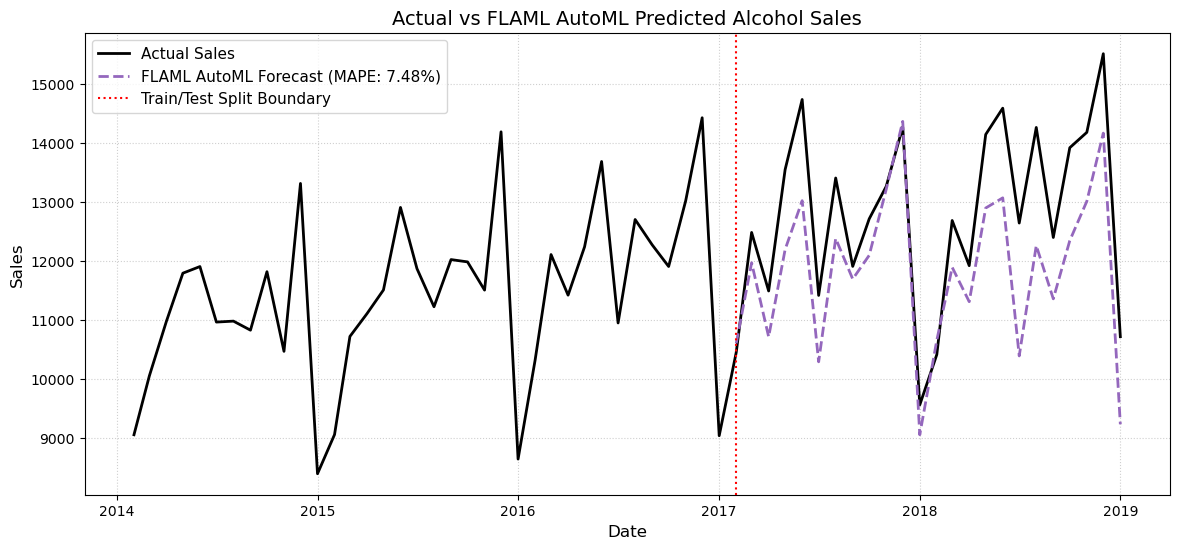

In [6]:
plt.figure(figsize=(14, 6))

# Plot the last year of train data and test data
plt.plot(df['DATE'].iloc[-60:], df['Sales'].iloc[-60:], label='Actual Sales', color='black', lw=2)
plt.plot(test_df['DATE'], automl_preds, label=f'FLAML AutoML Forecast (MAPE: {mape:.2%})', color='#9467bd', lw=2, linestyle='--')

plt.title('Actual vs FLAML AutoML Predicted Alcohol Sales', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Sales', fontsize=12)
plt.axvline(x=test_df['DATE'].iloc[0], color='red', linestyle=':', label='Train/Test Split Boundary')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=11, loc='upper left')
plt.show()

## 💡 6. Summary & Best Practices

- **Zero Manual Tuning:** FLAML automatically determines appropriate time series features, lags, Fourier frequencies, and parameters without manual intervention.
- **Cost Effective:** Evaluates dozens of configurations within seconds by focusing search steps around historical optimization paths.
- **Model Ensemble:** FLAML can build robust predictions by ensembling diverse methods to capture both long-term patterns and short-term trends.